# 3. 데이터 EDA (Exploratory Data Analysis)

---

## 수업 내용
- **데이터 EDA**
  - EDA란 무엇인가? 진행 순서
  - IQR 기반 이상치 탐지

- **데이터 시각화**
  - 단변수 분석: 히스토그램, 박스 플롯
  - 다변수 분석: 산점도, 회귀선(regplot), 히트맵, 페어 플롯

- **머신러닝 전처리**
  - 표준화 (StandardScaler) & Data Leakage 방지

- **모델 학습 & 검증**
  - Train/Test 데이터 분리
  - 회귀 평가 지표: RMSE, MAE, R²


---
# 0. 실습에 사용할 데이터셋

- **diamonds** (seaborn 내장 데이터셋)
- 다이아몬드 53,940개의 가격 및 물리적 특성 데이터
- 주요 컬럼
  - `carat` : 무게 (캐럿)
  - `cut` : 컷 품질 (Fair ~ Ideal)
  - `color` : 색상 등급 (D ~ J)
  - `clarity` : 투명도 등급
  - `depth`, `table` : 비율 수치
  - `price` : 가격 (USD)
  - `x`, `y`, `z` : 가로/세로/깊이 (mm)

> **목표**: 다이아몬드의 어떤 특성이 가격과 상관관계가 높은지 EDA를 통해 탐색한다.


In [21]:
%pip install seaborn
%pip install matplotlib
%pip install numpy
%pip install pandas
%pip install sklearn



You should consider upgrading via the '/Users/isaac/SSAFY/AI/15기_수업/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/Users/isaac/SSAFY/AI/15기_수업/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/Users/isaac/SSAFY/AI/15기_수업/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/Users/isaac/SSAFY/AI/15기_수업/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
    ERROR: Command errored out with exit status 1:
     command: '/Users/isaac/SSAFY/AI/15기_수업/.venv/bin/python' -c 'import io, os, sys, setuptools, tokenize; sys.argv[0] = '"'"'/private/var/folders/8r/0zrxssdd14v_x6w1j_

In [31]:
import platform
# 운영체제별 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 데이터 불러오기
df = sns.load_dataset("diamonds")

# 상위 5개 확인
df.head() 
# df.tail(n) 하위 n개 


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


---
# 1. EDA(Exploratory Data Analysis)란?

> **데이터를 본격적으로 분석하기 전에 여러 각도에서 관찰하고 이해하는 과정**

- 분석의 방향성을 결정하는 첫 단계
- 어떤 전처리가 필요한지, 어떤 모델을 쓸지 판단하는 근거가 됨

## EDA 진행 순서 (교안 슬라이드 6)

| 단계 | 내용 |
|------|------|
| 1 | 데이터 불러오기 + 기본 정보 확인 (타입, 결측치, 통계량) |
| 2 | 데이터 정제 및 전처리 (결측치·이상치·중복값 처리, 타입 수정) |
| 3 | 개별 변수 분석 (분포와 특징 이해) |
| 4 | 변수 간 관계 분석 (상관관계, 패턴 파악) |
| 5 | 분석 결과 정리 |

> 이 순서는 한 방향으로 딱 정해진 것이 아니라, 각 단계를 오가며 반복적으로 진행합니다.


## 1-1. 기본 정보 확인

In [4]:
# 데이터 크기 (행, 열)
print("shape:", df.shape)


shape: (53940, 10)


In [5]:
# 컬럼별 타입, 결측치, 메모리 사용량
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [6]:
# 수치형 컬럼 기술 통계량
# count, mean, std, min, 25%, 50%, 75%, max
df.describe()


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


> **읽는 법**
> - `count` : 결측치를 제외한 유효 데이터 수
> - `mean` : 평균 → 데이터가 전반적으로 어느 값대에 있는지
> - `std` (표준편차) : 평균에서 얼마나 퍼져있는지
> - `min` / `max` : 이상치 존재 여부를 빠르게 가늠
> - `25%`, `50%`, `75%` : 사분위수 → 분포의 형태를 수치로 확인


## 1-2. 결측치 확인

In [7]:
# 컬럼별 결측치 개수
missing = df.isnull().sum()
print(missing)
print()
print(f"총 결측치: {missing.sum()}개")


carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

총 결측치: 0개


---
# 2. IQR 기반 이상치 탐지 (교안 슬라이드 7)

## 이상치(Outlier)란?
- 대부분의 데이터 범위에서 크게 벗어난 극단적인 값

## IQR (Interquartile Range, 사분위 범위)
$$IQR = Q3(75\%) - Q1(25\%)$$

| 경계 | 공식 |
|------|------|
| 이상치 **하한** | Q1 − 1.5 × IQR |
| 이상치 **상한** | Q3 + 1.5 × IQR |

>  **핵심 규칙**: IQR 경계는 반드시 **Train 데이터**로만 계산해야 합니다.  
> Test 데이터의 통계 정보가 학습에 흘러들어오면 실전 성능이 낙관적으로 왜곡됩니다. (Data Leakage)


In [29]:
# price 컬럼의 IQR 기반 이상치 경계 계산
# dataframe.quantile(q=0.25) 
# q값에 따라 해당 행/열의 분위수의 해당하는 값을 반환하는 메서드
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.1f}")
print(f"Q3: {Q3:.1f}")
print(f"IQR: {IQR:.1f}")
print(f"이상치 하한: {lower:.1f}")
print(f"이상치 상한: {upper:.1f}")

# 이상치 개수 및 비율
outlier_mask = (df['price'] < lower) | (df['price'] > upper)
print(f"\n이상치 개수: {outlier_mask.sum()}개")
print(f"이상치 비율: {outlier_mask.mean()*100:.1f}%")


Q1: 950.0
Q3: 5324.2
IQR: 4374.2
이상치 하한: -5611.4
이상치 상한: 11885.6

이상치 개수: 3540개
이상치 비율: 6.6%


---
# 3. 데이터 시각화 (교안 슬라이드 9)

> 숫자 표보다 그래프가 데이터 패턴을 훨씬 직관적으로 보여줍니다.

| 라이브러리 | 역할 |
|-----------|------|
| **Matplotlib** | 파이썬 시각화의 근간. 그래프 크기·레이아웃·세부 설정 담당 |
| **Seaborn** | Matplotlib 기반. 통계적으로 의미 있는 그래프를 쉽게 그려줌 |

> 실습에서는 **Matplotlib으로 제목·축·라벨** 설정, **Seaborn으로 그래프** 그리기


---
## 3-1. 단변수 분석 — 히스토그램 (교안 슬라이드 10)

- **목적**: 하나의 수치형 변수가 어느 값에 몰려 있는지 (분포) 파악
- 전체 범위를 구간(bin)으로 나눠 각 구간의 데이터 개수를 막대로 표현

| 특징 | 내용 |
|------|------|
| 장점 | 분포를 직관적으로 파악 / 이상치 탐지에 유용 |
| 단점 | bin 설정에 따라 형태가 달라짐 |


/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/2787456098.py:14: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/2787456098.py:14: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/2787456098.py:14: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/2787456098.py:14: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/isaac/SSAFY/AI/15기_수업/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/isaac/SSAFY

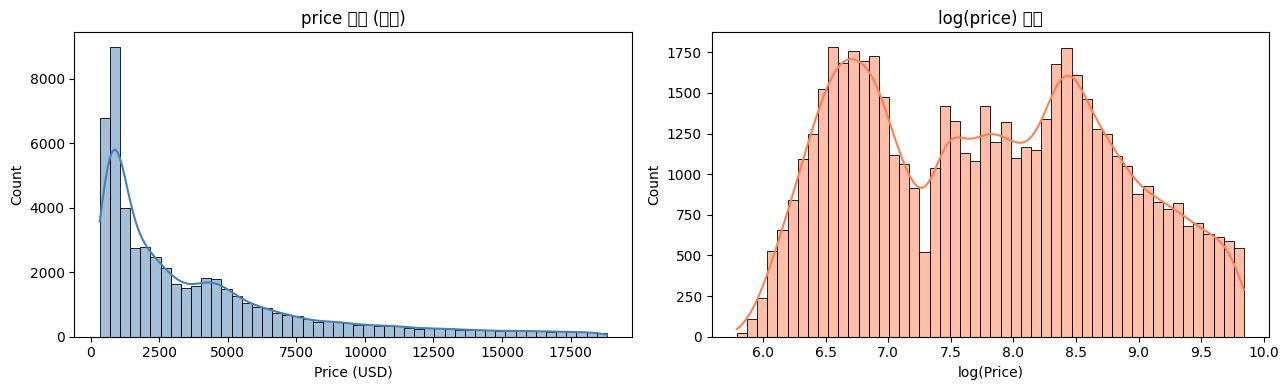

In [ ]:
# price(가격) 분포 확인
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 왼쪽: 원본 분포
sns.histplot(df['price'], bins=50, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('price 분포 (원본)')
axes[0].set_xlabel('Price (USD)')

# 오른쪽: 로그 변환 분포 (분포 치우침이 심할 때 완화하는 방법)
sns.histplot(np.log1p(df['price']), bins=50, kde=True, color='coral', ax=axes[1])
axes[1].set_title('log(price) 분포')
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
plt.show()


/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/119129885.py:10: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/119129885.py:10: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/isaac/SSAFY/AI/15기_수업/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/isaac/SSAFY/AI/15기_수업/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


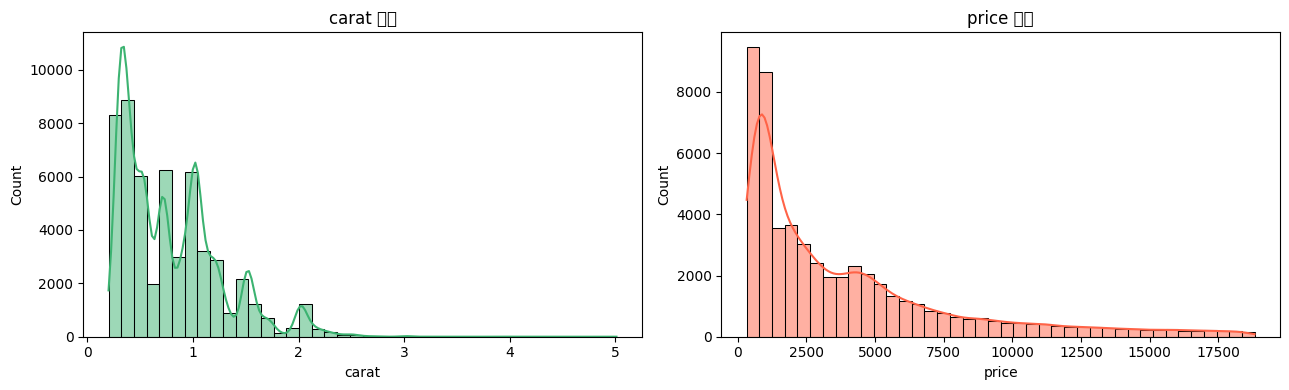

In [9]:
# carat(무게)과 price(가격) 분포를 함께 비교
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df['carat'], bins=40, kde=True, color='mediumseagreen', ax=axes[0])
axes[0].set_title('carat 분포')

sns.histplot(df['price'], bins=40, kde=True, color='tomato', ax=axes[1])
axes[1].set_title('price 분포')

plt.tight_layout()
plt.show()


---
## 3-2. 단변수 분석 — 박스 플롯 (교안 슬라이드 11)

- **목적**: 사분위수 기반으로 분포의 요약 + **이상치 식별**
- 히스토그램보다 이상치를 찾기 더 유용

| 요소 | 의미 |
|------|------|
| 박스 아래쪽 끝 | Q1 (하위 25%) |
| 박스 중간 선 | Q2 = 중앙값 (50%) |
| 박스 윗쪽 끝 | Q3 (상위 25%) |
| 수염 끝(위/아래) | Q1 − 1.5×IQR ~ Q3 + 1.5×IQR |
| 점(●) | 이상치 후보 |


/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/3329352884.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cut', y='price',
/Users/isaac/SSAFY/AI/15기_수업/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 46321 (\N{HANGUL SYLLABLE DEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/isaac/SSAFY/AI/15기_수업/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/isaac/SSAFY/AI/15기_수업/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/is

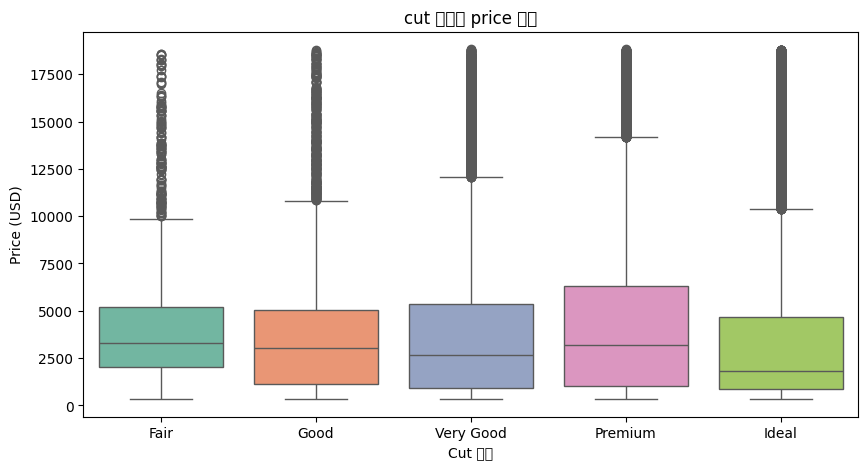

In [10]:
# cut(컷 품질)별 price 분포를 박스 플롯으로 비교
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='cut', y='price',
            order=['Fair','Good','Very Good','Premium','Ideal'],
            palette='Set2')
plt.title('cut 등급별 price 분포')
plt.xlabel('Cut 등급')
plt.ylabel('Price (USD)')
plt.show()


/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/1873434919.py:11: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/1873434919.py:11: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/1873434919.py:11: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/1873434919.py:11: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/1873434919.py:11: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ip

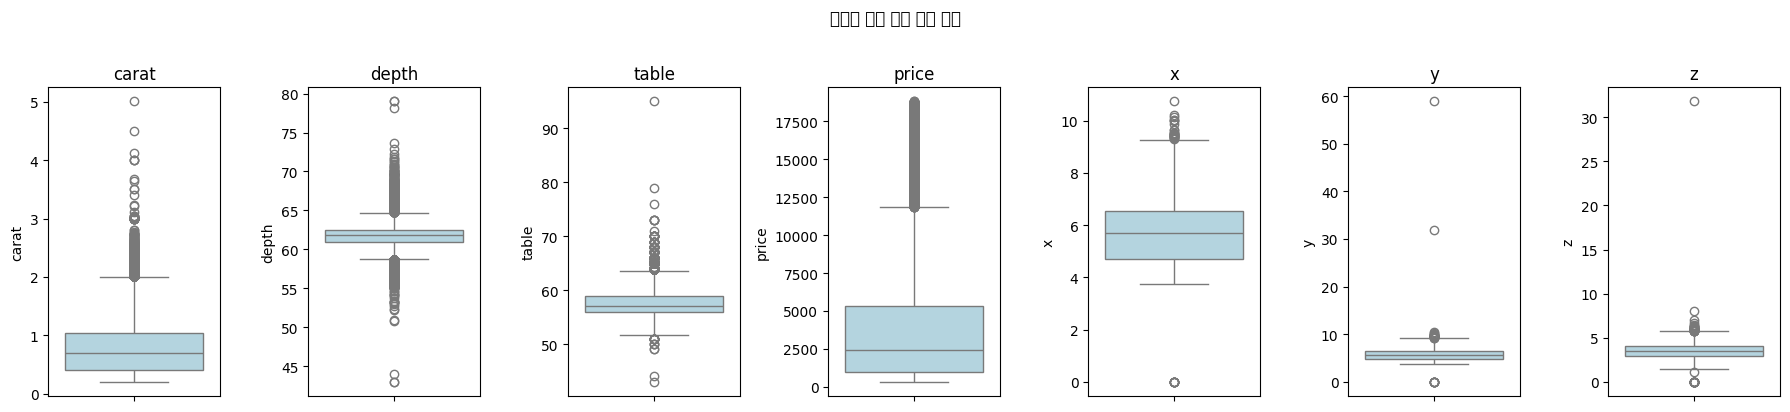

In [11]:
# 수치형 변수 전체 박스 플롯 — 이상치 한눈에 파악
numeric_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightblue')
    ax.set_title(col)
    ax.set_xlabel('')

plt.suptitle('수치형 변수 전체 박스 플롯', y=1.02)
plt.tight_layout()
plt.show()


---
## [참고] 상관관계 (Correlation) (교안 슬라이드 12)

> **두 변수가 함께 변화하는 관련성**

- 한 변수가 증가할 때 다른 변수가 어떻게 변하는지를 수치로 나타낸 것
- **−1 ~ +1** 사이의 값 → 이 값을 **상관계수(Correlation Coefficient)**라고 함

| 상관계수 값 | 의미 |
|------------|------|
| +1에 가까움 | 강한 양의 상관관계 (함께 증가) |
| 0에 가까움 | 상관관계 없음 |
| −1에 가까움 | 강한 음의 상관관계 (반대로 움직임) |

>  **주의**: 상관관계가 높다고 해서 **인과관계(원인-결과)**를 의미하지는 않습니다!  
> 예) 아이스크림 판매량 ↑ = 상어 공격 ↑ → 원인은 여름(기온)이라는 제3 변수


---
## 3-3. 다변수 분석 — 산점도 (Scatter Plot) (교안 슬라이드 13)

- **목적**: 두 수치형 변수 사이의 관계를 점으로 시각화
- 패턴, 이상치를 한눈에 발견

| 특징 | 내용 |
|------|------|
| 장점 | 두 변수의 관계를 직관적으로 파악 / 이상치 발견 용이 |
| 단점 | 데이터가 많으면 점이 겹침 / 인과관계는 알 수 없음 |


/Users/isaac/SSAFY/AI/15기_수업/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/isaac/SSAFY/AI/15기_수업/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/isaac/SSAFY/AI/15기_수업/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/isaac/SSAFY/AI/15기_수업/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/isaac/SSAFY/AI/15기_수업/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152

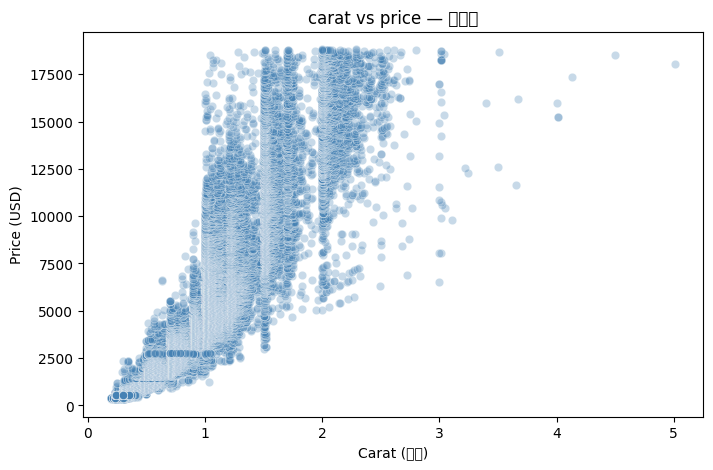

In [12]:
# carat과 price의 관계 — 산점도
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='carat', y='price', alpha=0.3, color='steelblue')
plt.title('carat vs price — 산점도')
plt.xlabel('Carat (무게)')
plt.ylabel('Price (USD)')
plt.show()


---
## 3-4. 산점도의 한계와 보완 방법 (교안 슬라이드 14)

> 산점도는 '느낌'에 의존 → 두 가지 방법으로 객관화

### ① 회귀선 추가 — `sns.regplot()`
- 점들의 전반적인 추세를 **선 하나**로 요약
- 기울기가 양수 → 양의 관계 / 음수 → 음의 관계

### ② 상관계수로 수치화 — `.corr()`
- −1 ~ +1 사이 값으로 관계의 방향과 강도를 **객관적**으로 표현
- 예) −0.77 → "강한 음의 상관관계"로 명확히 전달 가능


/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/486812263.py:15: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/486812263.py:15: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/486812263.py:15: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/486812263.py:15: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/486812263.py:15: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_6

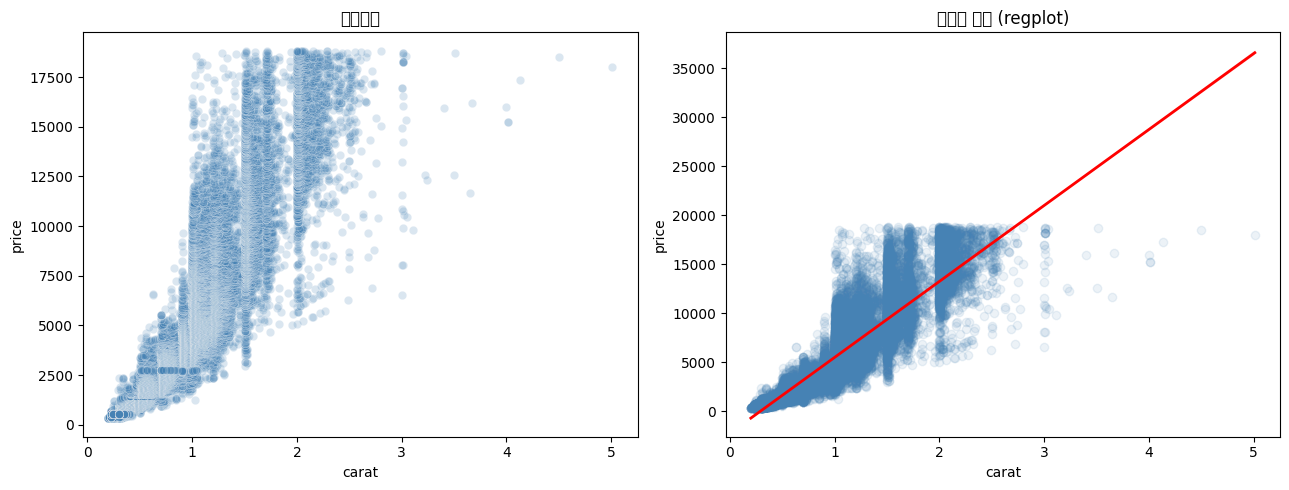

In [13]:
# 회귀선(regplot)으로 패턴 강화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 산점도 (비교용)
sns.scatterplot(data=df, x='carat', y='price', alpha=0.2, color='steelblue', ax=axes[0])
axes[0].set_title('산점도만')

# regplot: 산점도 + 회귀선
sns.regplot(data=df, x='carat', y='price',
            scatter_kws={'alpha': 0.1, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 2},
            ax=axes[1])
axes[1].set_title('회귀선 추가 (regplot)')

plt.tight_layout()
plt.show()


In [14]:
# 상관계수 수치로 확인
corr_value = df['carat'].corr(df['price'])
print(f"carat ↔ price 상관계수: {corr_value:.4f}")
print()
print("해석:", end=" ")
if corr_value > 0.7:
    print("강한 양의 상관관계")
elif corr_value > 0.3:
    print("약한 양의 상관관계")
elif corr_value > -0.3:
    print("상관관계 거의 없음")
elif corr_value > -0.7:
    print("약한 음의 상관관계")
else:
    print("강한 음의 상관관계")


carat ↔ price 상관계수: 0.9216

해석: 강한 양의 상관관계


---
### 문제 인식

> **변수가 7개라면 조합은 21가지 — 산점도를 21번 그려야 할까요?**

→ 아닙니다. 모든 변수 쌍의 상관계수를 **색상**으로 한눈에 보여주는 도구가 있습니다.  
→ 바로 **히트맵(Heatmap)** 입니다!


---
## 3-5. 다변수 분석 — 히트맵 (Heatmap) (교안 슬라이드 15)

- **목적**: 수많은 변수 쌍의 상관계수를 색상으로 한눈에 시각화
- 양의 상관(빨강) / 음의 상관(파랑)으로 직관적 파악

| 특징 | 내용 |
|------|------|
| 장점 | 다변량 관계를 한 번에 탐색 |
| 단점 | 정확한 수치 파악 어려움 / 변수 많으면 복잡해짐 |

### [참고] 왜 히트맵 절반을 지워도 되나요?
- 상관계수 행렬은 **수학적으로 대칭** → `corr(A, B) = corr(B, A)` 가 항상 성립
- 예) carat-price 상관계수 = price-carat 상관계수 → 우측 상단은 좌측 하단의 복사본
- **절반(삼각형)만 남겨도 모든 정보 유지 — 정보 손실 없는 단순화**


In [ ]:
# 전체 상관계수 행렬 계산 (수치형 변수만)
corr_matrix = df.select_dtypes(include='number').corr()
print(corr_matrix.round(2)) # 소수점 둘째 자리로 반올림


       carat  depth  table  price     x     y     z
carat   1.00   0.03   0.18   0.92  0.98  0.95  0.95
depth   0.03   1.00  -0.30  -0.01 -0.03 -0.03  0.09
table   0.18  -0.30   1.00   0.13  0.20  0.18  0.15
price   0.92  -0.01   0.13   1.00  0.88  0.87  0.86
x       0.98  -0.03   0.20   0.88  1.00  0.97  0.97
y       0.95  -0.03   0.18   0.87  0.97  1.00  0.95
z       0.95   0.09   0.15   0.86  0.97  0.95  1.00


/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/681686170.py:6: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/681686170.py:6: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/681686170.py:6: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/681686170.py:6: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/681686170.py:6: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/

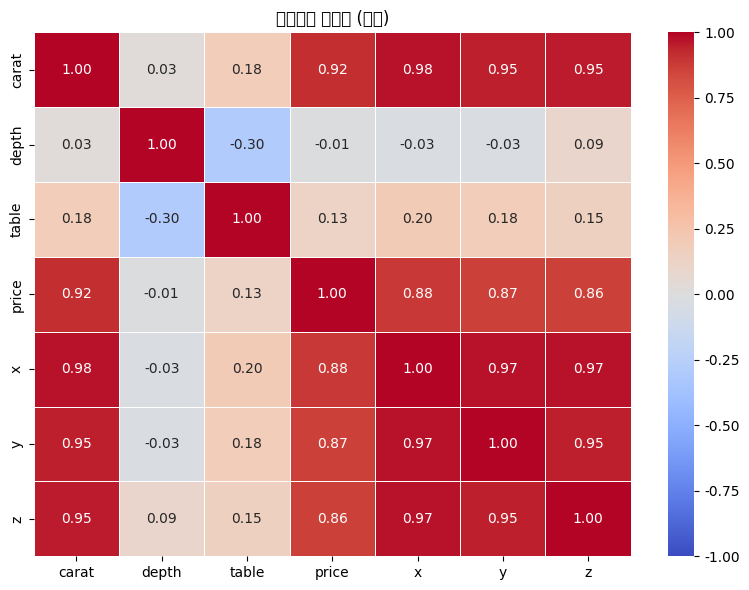

In [16]:
# 히트맵 시각화 (전체)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('상관계수 히트맵 (전체)')
plt.tight_layout()
plt.show()


/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/2011609980.py:11: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/2011609980.py:11: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/2011609980.py:11: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/2011609980.py:11: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/2011609980.py:11: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipyker

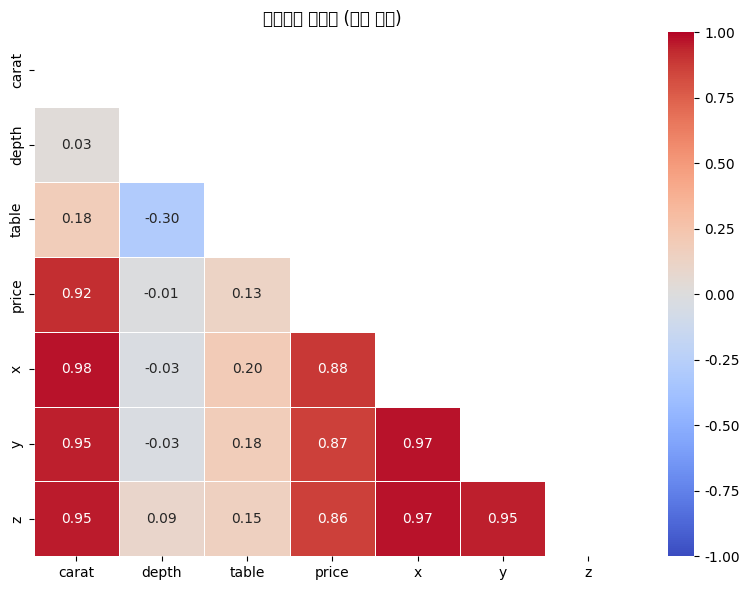

In [ ]:
# 히트맵 대칭 제거 — 삼각형 마스크 적용
import numpy as np

# 상단 삼각형 마스크 (True = 가리기)
# np.ones_like()는 입력 배열과 동일한 shape(모양)의 1로 채워진 배열을 만드는 함수
# dtype=bool을 추가하면 1 대신 Boolean(True)으로 채움.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('상관계수 히트맵 (대칭 제거)')
plt.tight_layout()
plt.show()


---
## 3-6. 다변수 분석 — 페어 플롯 (Pair Plot) (교안 슬라이드 16)

- **목적**: 여러 변수들의 **분포(대각선) + 관계(산점도)** 를 한 번에 탐색
- 히스토그램 + 산점도(+ 회귀선)를 하나의 그리드로 통합

| 위치 | 내용 |
|------|------|
| **대각선** | 각 변수의 분포도 |
| **대각선 외** | 두 변수 사이의 산점도 |

>  변수가 10개 이상이면 너무 복잡 → 핵심 변수만 선택해서 그리는 것이 일반적


/Users/isaac/SSAFY/AI/15기_수업/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/isaac/SSAFY/AI/15기_수업/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/isaac/SSAFY/AI/15기_수업/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/isaac/SSAFY/AI/15기_수업/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/isaac/SSAFY/AI/15기_수업/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152

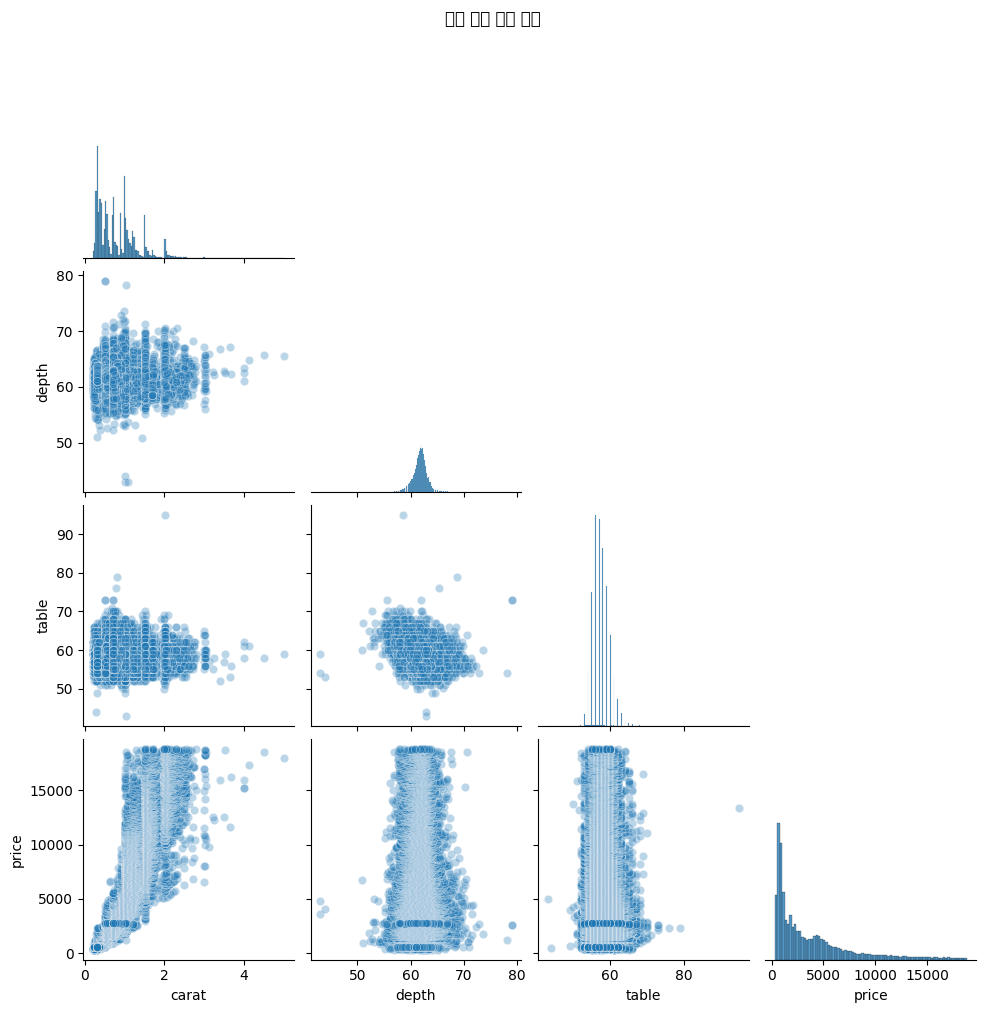

In [18]:
# 핵심 변수만 선택해서 페어플롯
key_cols = ['carat', 'depth', 'table', 'price']

sns.pairplot(df[key_cols], corner=True, plot_kws={'alpha': 0.3})
plt.suptitle('주요 변수 페어 플롯', y=1.01)
plt.show()


/Users/isaac/SSAFY/AI/15기_수업/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 46321 (\N{HANGUL SYLLABLE DEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/isaac/SSAFY/AI/15기_수업/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/isaac/SSAFY/AI/15기_수업/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


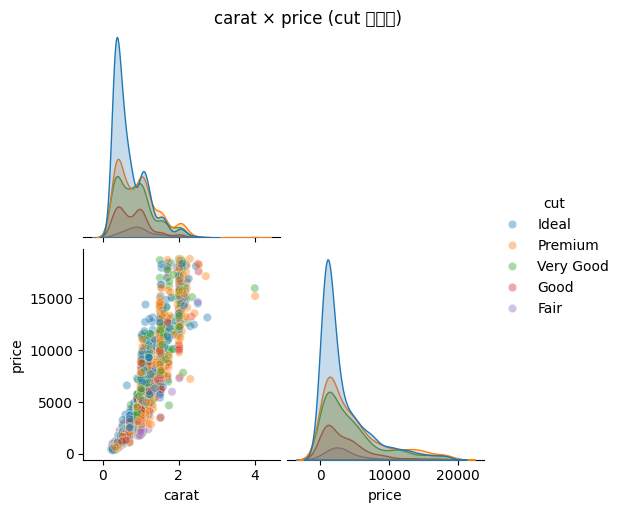

In [19]:
# 회귀선 포함 + cut 등급별 색상 구분
# (샘플링: 전체 5만 건이면 느리므로 3000개만)
df_sample = df.sample(3000, random_state=42)

sns.pairplot(df_sample[['carat', 'price', 'cut']], hue='cut',
             corner=True, plot_kws={'alpha': 0.4},
             diag_kind='kde')
plt.suptitle('carat × price (cut 등급별)', y=1.01)
plt.show()


---
# 4. 머신러닝 전처리 — 표준화 (교안 슬라이드 18)

## 표준화 (Standardization)란?
$$Z = \frac{x - \mu}{\sigma}$$

- 데이터 분포를 **평균 0, 표준편차 1**로 변환
- 단위가 다른 변수들의 스케일을 통일

### 왜 필요한가?
| 변수 | 범위 |
|------|------|
| `carat` | 0.2 ~ 5.0 |
| `price` | 326 ~ 18,823 |
- 단위가 다르면 모델이 큰 숫자(price)에 편향 → 학습 불안정
- 스케일을 맞추면 경사 하강법이 안정적으로 수렴

## 올바른 적용 순서 — **Data Leakage 방지**
```
① Train/Test 분할
② scaler.fit(X_train)     ← Train 데이터로만 통계 계산
③ X_train = scaler.transform(X_train)
④ X_test  = scaler.transform(X_test)  ← fit 없이 transform만!
```
> 잘못된 예: 전체 데이터로 fit() 후 분할 → Test 정보가 학습에 누출됨 (Data Leakage)


In [22]:
from sklearn.preprocessing import StandardScaler

# 수치형 변수만 선택 (타겟 price 제외)
feature_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']
X = df[feature_cols].copy()
y = df['price'].copy()

# 표준화 전 분포 확인
print("=== 표준화 전 ===")
print(X.describe().round(2))


=== 표준화 전 ===
          carat     depth     table         x         y         z
count  53940.00  53940.00  53940.00  53940.00  53940.00  53940.00
mean       0.80     61.75     57.46      5.73      5.73      3.54
std        0.47      1.43      2.23      1.12      1.14      0.71
min        0.20     43.00     43.00      0.00      0.00      0.00
25%        0.40     61.00     56.00      4.71      4.72      2.91
50%        0.70     61.80     57.00      5.70      5.71      3.53
75%        1.04     62.50     59.00      6.54      6.54      4.04
max        5.01     79.00     95.00     10.74     58.90     31.80


In [23]:
from sklearn.model_selection import train_test_split

# ① Train / Test 분할 (먼저!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(f"Train: {len(X_train)}개 / Test: {len(X_test)}개")


Train: 37758개 / Test: 16182개


In [ ]:
# ② Train 데이터로만 fit → ③ transform
scaler = StandardScaler()
# fit-> 평균(μ), 표준편차(σ) 계산 & 저장
scaler.fit(X_train) # Train 통계만 사용
# transform -> fit()에서 이미 구해둔 평균/표준편차로 표준화(변환)를 수행하는 단계
X_train_scaled = scaler.transform(X_train)  # Train 변환
X_test_scaled  = scaler.transform(X_test)   # Test는 transform만 (fit 없이!)

# 결과를 DataFrame으로 변환
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols)

print("=== 표준화 후 (Train) ===")
print(X_train_scaled_df.describe().round(3))


=== 표준화 후 (Train) ===
           carat      depth      table          x          y          z
count  37758.000  37758.000  37758.000  37758.000  37758.000  37758.000
mean       0.000      0.000      0.000      0.000     -0.000      0.000
std        1.000      1.000      1.000      1.000      1.000      1.000
min       -1.261    -13.121     -6.495     -5.111     -5.005     -4.977
25%       -0.841     -0.521     -0.656     -0.905     -0.880     -0.887
50%       -0.210      0.039     -0.207     -0.032     -0.025     -0.016
75%        0.505      0.529      0.691      0.717      0.699      0.701
max        8.853     12.078     16.859      4.459     46.365     39.721


/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/1010534077.py:14: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/1010534077.py:14: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/1010534077.py:14: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/1010534077.py:14: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipykernel_65588/1010534077.py:14: UserWarning: Glyph 46108 (\N{HANGUL SYLLABLE DOEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8r/0zrxssdd14v_x6w1j_7vxcwc0000gn/T/ipyk

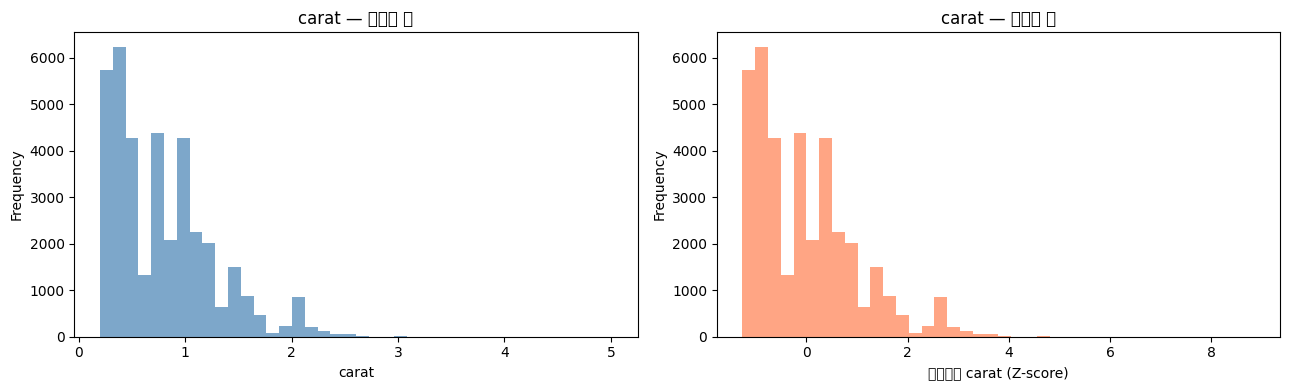

In [25]:
# 표준화 전/후 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 표준화 전
X_train.reset_index(drop=True)['carat'].plot(kind='hist', bins=40,
    color='steelblue', alpha=0.7, ax=axes[0], title='carat — 표준화 전')
axes[0].set_xlabel('carat')

# 표준화 후
X_train_scaled_df['carat'].plot(kind='hist', bins=40,
    color='coral', alpha=0.7, ax=axes[1], title='carat — 표준화 후')
axes[1].set_xlabel('표준화된 carat (Z-score)')

plt.tight_layout()
plt.show()


---
# 5. 모델 학습 — Train/Test 데이터 분리 (교안 슬라이드 19~20)

## 왜 나눠야 할까?
- 학습 데이터만으로 평가하면 "공부한 문제를 다시 푸는 것"과 같음
- **새로운 데이터에서도 잘 작동하는지** 확인하기 위해 → **일반화(Generalization)**

## train_test_split 파라미터

| 파라미터 | 의미 |
|---------|------|
| `test_size=0.3` | 전체의 30%를 테스트용으로 |
| `random_state=42` | 고정된 랜덤 시드 (재현성 확보) |
| `stratify=y` | 타겟 비율 유지 (분류 문제에서 필수) |


In [26]:
# 이미 위에서 분할했지만 명시적으로 다시 확인
print(f"전체 데이터: {len(X)}개")
print()
print(f"Train: {len(X_train)}개 ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test : {len(X_test)}개  ({len(X_test)/len(X)*100:.0f}%)")


전체 데이터: 53940개

Train: 37758개 (70%)
Test : 16182개  (30%)


## [참고] 검증 데이터 (Validation Data) (교안 슬라이드 21)

| 데이터 | 역할 | 비율 |
|--------|------|------|
| Train | 모델 학습 | ~70% |
| **Validation** | 학습 중 성능 모니터링, 하이퍼파라미터 조정 | ~15% |
| Test | 최종 성능 평가 (학습에 절대 사용 금지) | ~15% |

> 이번 실습에서는 단순 선형 회귀 1개만 사용하므로 Validation은 생략합니다.  
> 신경망 모델에서는 필수적으로 사용합니다.


---
# 6. 모델 학습 및 평가 (교안 슬라이드 22)

## 회귀 모델 평가 지표

| 지표 | 공식 | 해석 |
|------|------|------|
| **MSE** | 오차² 평균 | 0에 가까울수록 좋음 |
| **RMSE** | √MSE | 타겟과 같은 단위로 해석 가능 |
| **MAE** | 절댓값 오차 평균 | 이상치에 덜 민감 |
| **R²** | 결정계수 (0~1) | 1에 가까울수록 데이터를 잘 설명 |

> 세 지표를 함께 볼 것: **RMSE는 큰 실수 감지, MAE는 평균 오차, R²는 전체 설명력**


In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 모델 학습 (표준화된 데이터 사용)
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 예측
y_pred = model.predict(X_test_scaled)

# 평가 지표 계산
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("=== 선형 회귀 모델 평가 ===")
print(f"MSE  : {mse:,.1f}")
print(f"RMSE : {rmse:,.1f}  ← 예측이 평균 ${rmse:,.0f} 수준으로 빗나감")
print(f"MAE  : {mae:,.1f}")
print(f"R²   : {r2:.4f}  ← 데이터 변동의 {r2*100:.1f}%를 설명")


=== 선형 회귀 모델 평가 ===
MSE  : 2,189,040.8
RMSE : 1,479.5  ← 예측이 평균 $1,480 수준으로 빗나감
MAE  : 885.3
R²   : 0.8596  ← 데이터 변동의 86.0%를 설명


---
# 7. 정리

| 단계 | 내용 | 주요 도구 |
|------|------|----------|
| EDA 개요 | 데이터 구조·결측치·통계량 파악 | `df.info()`, `df.describe()` |
| 이상치 탐지 | IQR 기반 이상치 경계 계산 | `quantile()` |
| 히스토그램 | 단변수 분포 파악 | `sns.histplot()` |
| 박스 플롯 | 분포 요약 + 이상치 시각화 | `sns.boxplot()` |
| 산점도·regplot | 두 변수 관계 + 회귀선 | `sns.scatterplot()`, `sns.regplot()` |
| 상관계수 | 관계 강도 수치화 | `.corr()` |
| 히트맵 | 전체 변수 상관관계 한눈에 | `sns.heatmap()` |
| 페어 플롯 | 분포 + 관계 통합 탐색 | `sns.pairplot()` |
| 표준화 | Data Leakage 없는 전처리 | `StandardScaler` |
| 모델 평가 | RMSE, MAE, R² 해석 | `sklearn.metrics` |

---

>  **EDA는 정답이 없는 과정입니다.**  
> 데이터를 이해하고, 질문을 만들고, 시각화로 확인하는 반복이 핵심입니다.
